In [1]:
from typing import TypedDict, List, Optional
from pydantic import BaseModel, Field
from typing import List, Optional
from dotenv import load_dotenv
from pydantic import BaseModel

#### Agent State

In [2]:
class InteractionData(BaseModel):
    hcp_name: Optional[str]
    date: Optional[str]
    time: Optional[str]
    topics: Optional[str]
    materials: Optional[List[str]] = Field(
        default=None,
        description="List of materials (ALWAYS return as list, even if single item)"
    )
    sentiment: Optional[str]

In [3]:
class InteractionState(TypedDict):
    input: str
    intent: Optional[str]
    interaction_data: dict   # ✅ fixed name + use dict for merging
    messages: List[str]
    status: Optional[str]
    missing_data_question: Optional[str]

#### Pydantic Model (Pydantic Models (Structured Output)):

In [4]:
class InteractionExtraction(BaseModel):
    hcp_name: Optional[str]
    date: Optional[str]
    time: Optional[str]
    attendees: Optional[str]
    topics: Optional[str]
    materials: Optional[List[str]] = Field(
        default=None,
        description="List of materials (ALWAYS return as list, even if single item)"
    )
    sentiment: Optional[str]
    outcomes: Optional[str]
    follow_up: Optional[str]


class EditExtraction(BaseModel):
    hcp_name: Optional[str]
    date: Optional[str]
    time: Optional[str]
    attendees: Optional[str]
    topics: Optional[str]
    materials: Optional[List[str]]
    sentiment: Optional[str]
    outcomes: Optional[str]
    follow_up: Optional[str]


class QueryExtraction(BaseModel):
    field: str
    value: str

In [5]:
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [7]:
class IntentOutput(BaseModel):
    intent: str

def intent_node(state: InteractionState):
    print("----------------------------------------------------")
    print("inside intent_node")
    structured_llm = llm.with_structured_output(IntentOutput)

    prompt = f"""
    Classify user intent into one of:
    - log
    - edit
    - query_type
    - query_sentiment
    - followup

    Input: {state["input"]}
    """

    result = structured_llm.invoke(prompt)
    print(result.intent)
    print("----------------------------------------------------")
    
    return {"intent": result.intent}

In [8]:
# test_inputs = [
#     "Today I met Dr Smith and discussed product X",
#     "Sorry change sentiment to negative",
#     "Show all HCPs with meeting interaction",
#     "Show all doctors with positive sentiment",
#     "Suggest follow-up for Dr Smith"
# ]

# for text in test_inputs:
#     state = {"input": text}
#     result = intent_node(state)
#     print(f"Input: {text}")
#     print(f"Intent: {result['intent']}")
#     print("-" * 50)

In [9]:
def save_to_db(d):
    print(d)
    print("data saved to db")

In [10]:
def log_node(state: InteractionState):
    print("----------------------------------------------------")
    
    print("inside log_node")
    structured_llm = llm.with_structured_output(InteractionData)

    extraction = structured_llm.invoke(state["input"])
    new_data = extraction.dict(exclude_none=True)

    # ✅ get existing data safely
    current_data = state.get("interaction_data", {})

    # ✅ merge
    updated = {**current_data, **new_data}

    required = ["hcp_name", "date", "time", "topics", "sentiment"]
    missing = [f for f in required if not updated.get(f)]

    if missing:
        state["status"] = "incomplete"
        question = f"Please provide: {', '.join(missing)}"

        return {
            "interaction_data": updated,
            "status": "incomplete",
            "missing_data_question": question,
            "messages": state.get("messages", []) + [question]
        }

    # Complete → save
    last_id = save_to_db(updated)

    return {
        "interaction_data": updated,
        "status": "complete",
        "messages": state.get("messages", []) + ["Interaction saved successfully"],
        "last_id": last_id
    }

In [11]:
# def log_node(state: InteractionState):
#     structured_llm = llm.with_structured_output(InteractionExtraction)

#     prompt = f"""
#     Extract structured interaction data.

#     IMPORTANT:
#     - materials must be a list

#     Input:
#     {state["input"]}
#     """

#     result = structured_llm.invoke(prompt)
#     data = result.dict(exclude_none=True)

#     # 🔥 FIX: enforce list
#     if "materials" in data and isinstance(data["materials"], str):
#         data["materials"] = [data["materials"]]

#     return data

In [12]:
def edit_node(state: InteractionState):
    structured_llm = llm.with_structured_output(EditExtraction)

    prompt = f"""
    Current data:
    {state}

    Update based on:
    {state["input"]}

    Only return changed fields.
    """

    result = structured_llm.invoke(prompt)

    return result.dict(exclude_none=True)

In [13]:
def query_type_node(state: InteractionState):
    structured_llm = llm.with_structured_output(QueryExtraction)

    prompt = f"""
    Extract query filter from:
    {state["input"]}

    Example:
    field = interaction_type
    value = meeting
    """

    result = structured_llm.invoke(prompt)

    # simulate DB
    fake_db = [
        {"hcp_name": "Dr. Smith", "interaction_type": "meeting"},
        {"hcp_name": "Dr. John", "interaction_type": "call"},
    ]

    filtered = [
        x for x in fake_db if x.get(result.field) == result.value
    ]

    return {"result": filtered}

In [14]:
def query_sentiment_node(state: InteractionState):
    structured_llm = llm.with_structured_output(QueryExtraction)

    prompt = f"""
    Extract sentiment filter from:
    {state["input"]}
    """

    result = structured_llm.invoke(prompt)

    fake_db = [
        {"hcp_name": "Dr. Smith", "sentiment": "positive"},
        {"hcp_name": "Dr. John", "sentiment": "negative"},
    ]

    filtered = [
        x for x in fake_db if x.get(result.field) == result.value
    ]

    return {"result": filtered}

In [15]:
def followup_node(state: InteractionState):
    prompt = f"""
    Based on this interaction:
    {state}

    Suggest a follow-up action.
    """

    response = llm.invoke(prompt)

    return {"follow_up": response.content}

In [16]:
def route(state: InteractionState):
    intent = state["intent"]

    if intent == "log":
        return "log"
    elif intent == "edit":
        return "edit"
    elif intent == "query_type":
        return "query_type"
    elif intent == "query_sentiment":
        return "query_sentiment"
    elif intent == "followup":
        return "followup"

In [17]:
from langgraph.graph import StateGraph

builder = StateGraph(InteractionState)

builder.add_node("intent", intent_node)
builder.add_node("log", log_node)
builder.add_node("edit", edit_node)
builder.add_node("query_type", query_type_node)
builder.add_node("query_sentiment", query_sentiment_node)
builder.add_node("followup", followup_node)

builder.set_entry_point("intent")

builder.add_conditional_edges(
    "intent",
    route,
    {
        "log": "log",
        "edit": "edit",
        "query_type": "query_type",
        "query_sentiment": "query_sentiment",
        "followup": "followup",
    }
)

builder.set_finish_point("log")
builder.set_finish_point("edit")
builder.set_finish_point("query_type")
builder.set_finish_point("query_sentiment")
builder.set_finish_point("followup")

graph = builder.compile()

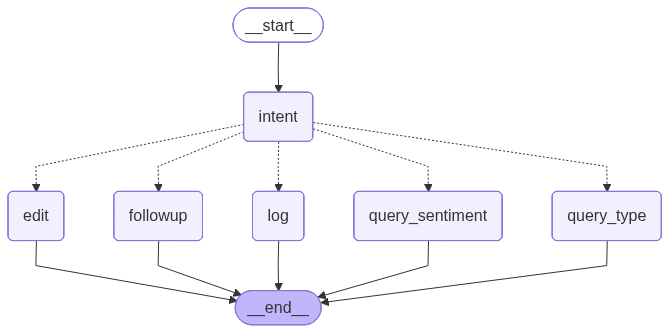

In [18]:
graph

In [20]:
state = {
    "input": "Today I met Dr Smith"
}

result = graph.invoke(state)

print(result)

----------------------------------------------------
inside intent_node
log
----------------------------------------------------
----------------------------------------------------
inside log_node
{'input': 'Today I met Dr Smith', 'intent': 'log', 'interaction_data': {'hcp_name': 'Dr Smith', 'date': 'today'}, 'messages': ['Please provide: time, topics, sentiment'], 'status': 'incomplete', 'missing_data_question': 'Please provide: time, topics, sentiment'}


C:\Users\Naruto\AppData\Local\Temp\ipykernel_3916\1720169809.py:8: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  new_data = extraction.dict(exclude_none=True)


In [21]:
result

{'input': 'Today I met Dr Smith',
 'intent': 'log',
 'interaction_data': {'hcp_name': 'Dr Smith', 'date': 'today'},
 'messages': ['Please provide: time, topics, sentiment'],
 'status': 'incomplete',
 'missing_data_question': 'Please provide: time, topics, sentiment'}